## Evaluate ERA-Interim Cross validation


In [1]:
import os
import sys

import numpy as np
import pandas as pd
import xarray as xr
import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'eval_transferability')[0]

sys.path.append(os.path.sep.join([base_dir , 'src']))
from help_fcts import get_rmse, get_mae, get_mbe, get_r2, calc_anomaly

fig_dir = os.path.sep.join([base_dir, 'figures_transf', 'ERAI_smallNN'])
os.makedirs(fig_dir, exist_ok=True)

In [3]:
# load daily melt predictions
chunking = {'time': -1, 'y': -1, 'x': -1}
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_ERAI_modularNNEBM'])
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_CESM2_modularNNEBM_mse'])
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_ERAI_modularNNEBM_noshuffle'])
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_ERAI_modularNNEBM_noshuffle_smallNN_transform_20260515_144453'])


# load climatology of true melt
ds_clim = xr.open_dataset(os.path.sep.join([base_dir, 'data', 'interim', 'ERAI', 'HIRHAM5', 'firnpack', 'climat_1990-2016_smoothed15.nc']))
snmel_clim = ds_clim['snmel']
snmel_clim


<xarray.DataArray 'snmel' (time: 366, y: 602, x: 402)> Size: 354MB
[88573464 values with dtype=float32]
Coordinates:
    lon      (y, x) float32 968kB ...
    lat      (y, x) float32 968kB ...
  * time     (time) datetime64[ns] 3kB 1980-01-01T12:00:00 ... 1980-12-31T12:...
Dimensions without coordinates: y, x
Attributes:
    long_name:  Acc snow melt
    units:      mm/day weq
    height:     0.0
    time:       365.75

## Calculate Scores on validation sets

In [4]:
# Tables 5: Basin-wise scores per year
# this takes a few minutes ...

years = range(2000, 2015, 2)
years = [1996,2004]
iter_n = range(5)
scaling_factor = 1.796553703424 / 58391 

metrics = ['true melt', 'predicted melt', 'RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']

# Create multi-level index (years × categories)
index = pd.MultiIndex.from_product([years, iter_n], names=['year', 'iter'])

# Create DataFrame with this index and metric columns
df_per_year = pd.DataFrame(np.nan,  index=index, dtype=float, 
    columns=metrics)

for year in years:
    for it in iter_n:
        try:
            data_dir = os.path.sep.join([pred_dir, f'fold_{year}', f'iter_{it}', 'pred_val.zarr'])
            print(f'Load data {data_dir} ...')
            ds_pred = xr.open_dataset(data_dir).chunk(chunking)
            pred_da = ds_pred['snmel_pred'].compute()
            true_da = ds_pred['snmel_true'].compute()

            residual = pred_da - true_da
            df_per_year.loc[(year,it), 'true melt'] = true_da.sum(dim=['time','x','y']).item()*scaling_factor
            df_per_year.loc[(year,it), 'predicted melt'] = pred_da.sum(dim=['time','x','y']).item()*scaling_factor
            df_per_year.loc[(year,it), 'RMSE'] = get_rmse(residual)
            df_per_year.loc[(year,it), 'MAE'] = get_mae(residual)
            df_per_year.loc[(year,it), 'MBE'] = get_mbe(residual)
            df_per_year.loc[(year,it), 'R2'] = get_r2(true_da.values, pred_da.values)

            #print('Calculate anomalies')
            anomaly_pred, _, _ = calc_anomaly(pred_da, ds_clim['snmel'].sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int)))
            anomaly_true, _, _ = calc_anomaly(true_da, ds_clim['snmel'].sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int)))
            df_per_year.loc[(year,it), 'R2_anomalies'] = get_r2(anomaly_true.values, anomaly_pred.values)
        except Exception as e:
            pass

display(df_per_year.round(2))

Load data /home/eschlager/MeltEmulation/output/crossval_ERAI_modularNNEBM_noshuffle_smallNN_transform_20260515_144453/fold_1996/iter_0/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_ERAI_modularNNEBM_noshuffle_smallNN_transform_20260515_144453/fold_1996/iter_1/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_ERAI_modularNNEBM_noshuffle_smallNN_transform_20260515_144453/fold_1996/iter_2/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_ERAI_modularNNEBM_noshuffle_smallNN_transform_20260515_144453/fold_1996/iter_3/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_ERAI_modularNNEBM_noshuffle_smallNN_transform_20260515_144453/fold_1996/iter_4/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_ERAI_modularNNEBM_noshuffle_smallNN_transform_20260515_144453/fold_2004/iter_0/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_ERAI_modularNNEBM_noshuffl

true melt  predicted melt  RMSE   MAE   MBE    R2  R2_anomalies
year iter                                                                 
1996 0        455.79          461.48  0.80  0.12  0.01  0.95          0.86
     1        455.79          454.30  0.81  0.13 -0.00  0.95          0.86
     2        455.79          469.06  0.80  0.14  0.02  0.95          0.86
     3        455.79          462.95  0.81  0.13  0.01  0.95          0.86
     4        455.79          476.11  0.80  0.14  0.03  0.95          0.86
2004 0        595.81          603.39  0.85  0.14  0.01  0.96          0.83
     1        595.81          599.65  0.85  0.14  0.01  0.96          0.83
     2        595.81          604.74  0.85  0.15  0.01  0.96          0.83
     3        595.81          612.66  0.85  0.16  0.03  0.96          0.83
     4        595.81          599.81  0.86  0.15  0.01  0.96          0.83

In [5]:
# mean and std per year, across repeated trainings
stats = df_per_year.groupby(level='year').agg(['mean', 'std'])
display(stats.round(2))

true melt      predicted melt        RMSE         MAE         MBE        \
          mean  std           mean   std  mean   std  mean   std  mean   std   
year                                                                           
1996    455.79  0.0         464.78  8.23  0.81  0.01  0.13  0.01  0.01  0.01   
2004    595.81  0.0         604.05  5.30  0.85  0.01  0.15  0.01  0.01  0.01   

        R2      R2_anomalies       
      mean  std         mean  std  
year                               
1996  0.95  0.0         0.86  0.0  
2004  0.96  0.0         0.83  0.0

In [6]:
# mean and std across all years and repeated trainings
stats_all = df_per_year.agg(['mean', 'std'])
stats_all

,true melt,predicted melt,RMSE,MAE,MBE,R2,R2_anomalies
mean,525.798866,534.417791,0.828596,0.141396,0.013107,0.955381,0.843219
std,73.798363,73.692462,0.024464,0.011434,0.009941,0.005425,0.015734


## Create distribution plots per skill metric

In [7]:
import seaborn as sns
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = cmap.colors

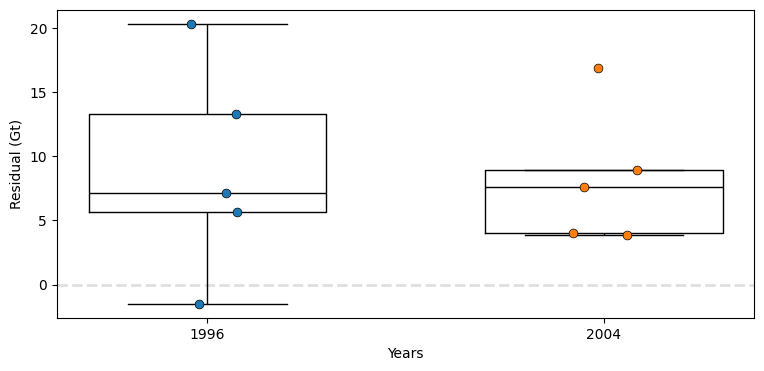

In [8]:
# Plot of residuals per year in Gt

df_per_year['residual'] = df_per_year['predicted melt'] - df_per_year['true melt']

for metric_to_plot in ['residual']:
    fig, ax = plt.subplots(figsize=(9,4))
    ax.axhline(y=0, color='silver', alpha=0.5, linestyle='--', linewidth=2, zorder=-5)
    # ax.axhspan(ymin=stats_all[metric_to_plot]['mean']-stats_all[metric_to_plot]['std'], ymax=stats_all[metric_to_plot]['mean']+stats_all[metric_to_plot]['std'], 
    #            color='silver', alpha=0.2)
    for i,bb in enumerate(years):
        dff = df_per_year.xs(bb, level='year')[metric_to_plot]
        #vp = ax.violinplot(data=dff, inner="point", density_norm="count")
        vp = sns.boxplot(dff.values, positions=[i], showfliers=False, widths=0.6, fill=False, color='k', linewidth=1, ax=ax, zorder=-1)
        
        ax.scatter((np.random.rand(len(dff)))*0.2+i-0.1, dff.values, s=40, color=colors[i], linewidth=0.5, edgecolors='k', alpha=1., zorder=1)
        ax.set_xticks(np.arange(len(years)))
        ax.set_xticklabels(years)
        ax.set_ylabel('Residual (Gt)')
        ax.set_xlabel('Years')
        fig.savefig(os.path.sep.join([fig_dir, f"crossval_boxplot{metric_to_plot}.png"]), bbox_inches='tight', dpi=200)

    plt.show()

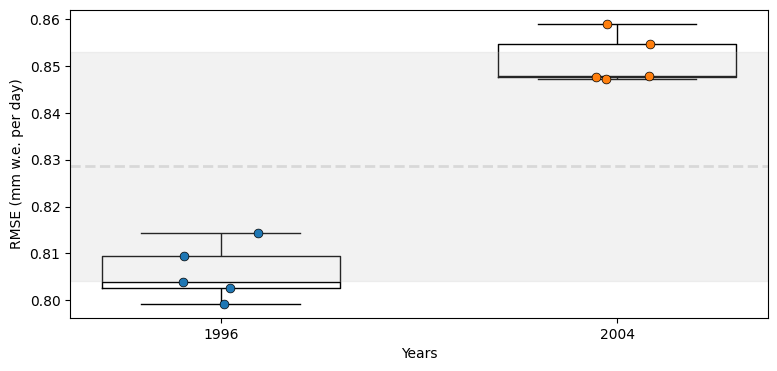

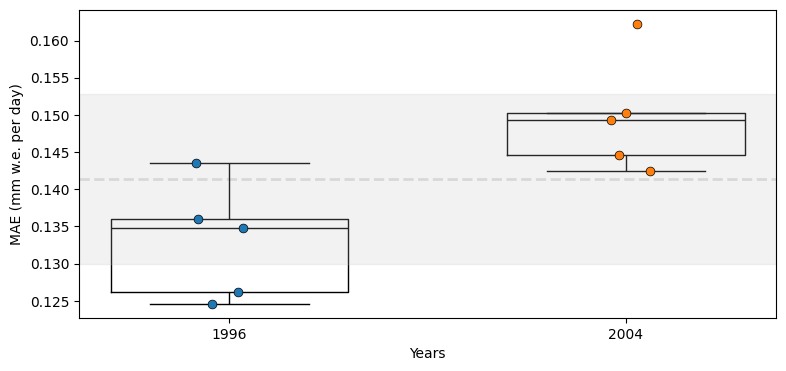

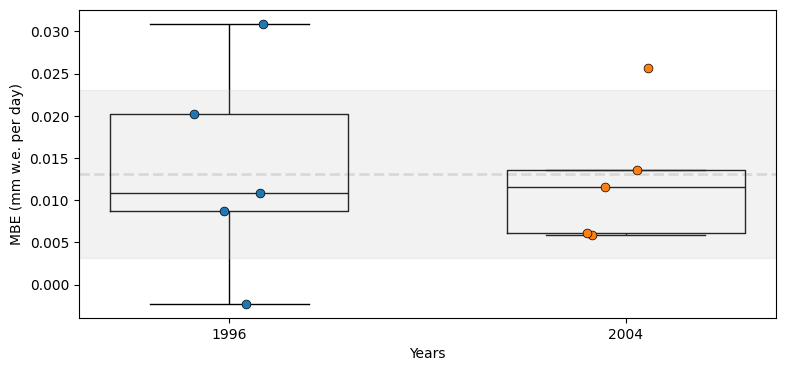

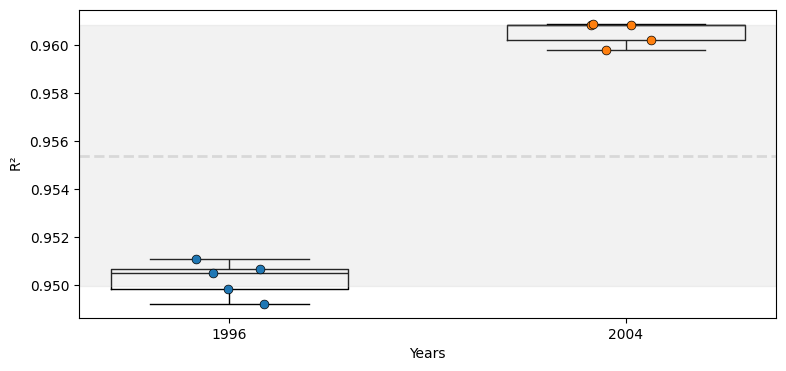

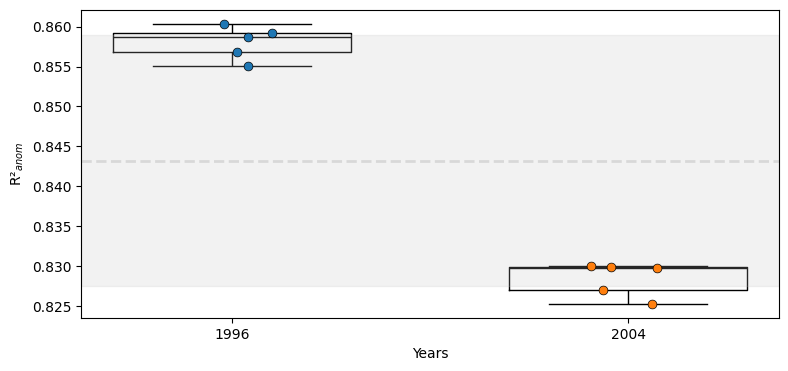

In [9]:
import seaborn as sns
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = cmap.colors

for metric_to_plot in ['RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']:
    fig, ax = plt.subplots(figsize=(9,4))
    ax.axhline(y=stats_all[metric_to_plot]['mean'], color='silver', alpha=0.5, linestyle='--', linewidth=2, zorder=-5)
    ax.axhspan(ymin=stats_all[metric_to_plot]['mean']-stats_all[metric_to_plot]['std'], ymax=stats_all[metric_to_plot]['mean']+stats_all[metric_to_plot]['std'], 
               color='silver', alpha=0.2)
    for i,bb in enumerate(years):
        dff = df_per_year.xs(bb, level='year')[metric_to_plot]
        vp = sns.boxplot(dff.values, positions=[i], showfliers=False, widths=0.6, fill=False, color='k', linewidth=1, ax=ax, zorder=-1)
        ax.scatter((np.random.rand(len(dff)))*0.2+i-0.1, dff.values, s=40, color=colors[i], linewidth=0.5, edgecolors='k', alpha=1., zorder=1)
        
        ax.set_xticks(np.arange(len(years)))
        ax.set_xticklabels(years)
        if metric_to_plot=='R2':
            ax.set_ylabel('R$²$')
        elif metric_to_plot=='R2_anomalies':
            ax.set_ylabel('R$²_{anom}$')
        else:
            ax.set_ylabel(metric_to_plot+' (mm w.e. per day)')
        ax.set_xlabel('Years')
        
        fig.savefig(os.path.sep.join([fig_dir, f"crossval_boxplot{metric_to_plot}.png"]), bbox_inches='tight', dpi=200)

    plt.show()

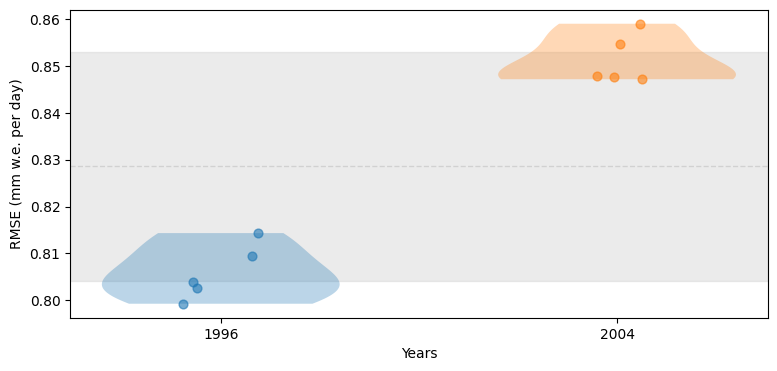

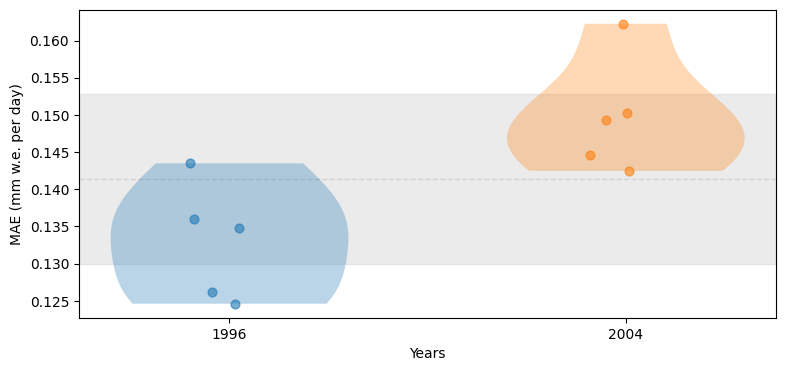

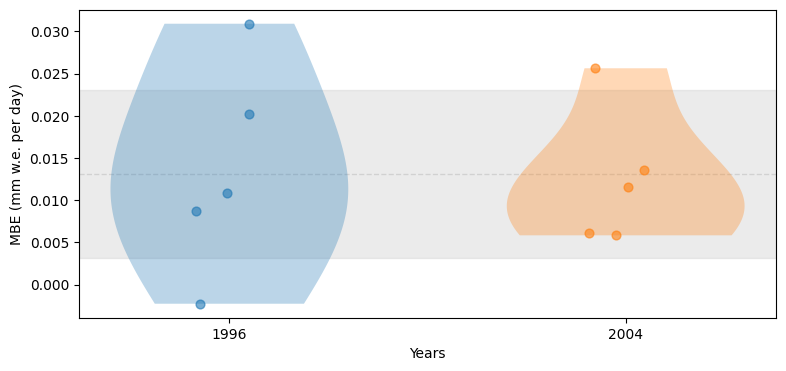

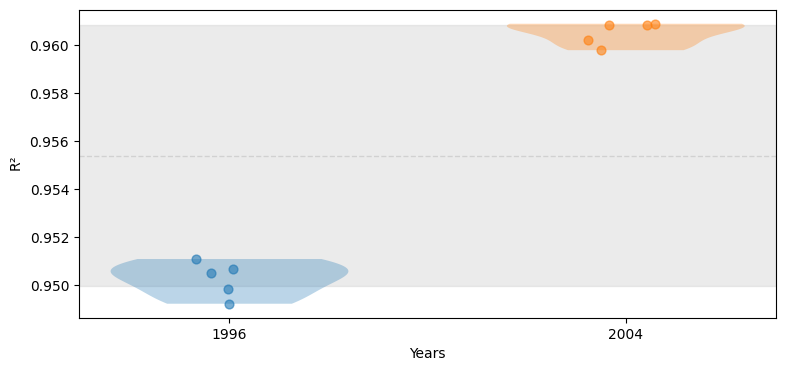

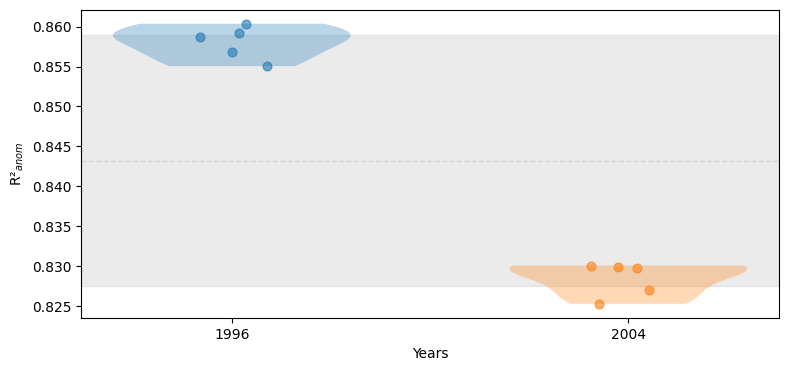

In [10]:
import seaborn as sns
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = cmap.colors

for metric_to_plot in ['RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']:
    fig, ax = plt.subplots(figsize=(9,4))
    ax.axhline(y=stats_all[metric_to_plot]['mean'], color='silver', alpha=0.6, linestyle='--', linewidth=1, zorder=-5)
    ax.axhspan(ymin=stats_all[metric_to_plot]['mean']-stats_all[metric_to_plot]['std'], ymax=stats_all[metric_to_plot]['mean']+stats_all[metric_to_plot]['std'], 
               color='silver', alpha=0.3)
    for i,bb in enumerate(years):
        dff = df_per_year.xs(bb, level='year')[metric_to_plot]
        vp = ax.violinplot(dff.values, positions=[i], widths=0.6, showmedians=False, showextrema=False)
        for pc in vp['bodies']:
            pc.set_facecolor(colors[i])
            pc.set_alpha(0.3)  # 0.5 = 50% transparent
        plt.scatter((np.random.rand(len(dff)))*0.2+i-0.1, dff.values, s=40, color=colors[i], linewidth=None, alpha=0.6)

        ax.set_xticks(np.arange(len(years)))
        ax.set_xticklabels(years)
        if metric_to_plot=='R2':
            ax.set_ylabel('R$²$')
        elif metric_to_plot=='R2_anomalies':
            ax.set_ylabel('R$²_{anom}$')
        else:
            ax.set_ylabel(metric_to_plot+' (mm w.e. per day)')
        ax.set_xlabel('Years')
        
        fig.savefig(os.path.sep.join([fig_dir, f"crossval_violinplot{metric_to_plot}.png"]), bbox_inches='tight', dpi=200)

    plt.show()